In [1]:
import gymnasium_env as drausp_env
import numpy as np
from pathlib import Path

from instance_reader import get_instance_data
import matplotlib.pyplot as plt

data_path = Path("../instances/lion18s/SA01.txt")

In [2]:
DRAUSP_data = get_instance_data(data_path)

K = DRAUSP_data.num_slots
T_d = DRAUSP_data.num_requests
C_k = DRAUSP_data.capacity_vector
instance = DRAUSP_data.instance
print(K)
print(T_d)
print(C_k)
print(instance)

4
50
[10, 10, 10, 10]
[[41, 1, 1, 0, 0], [39, 1, 1, 0, 0], [20, 1, 3, 0, 0], [61, 2, 1, 0, 0], [18, 2, 1, 0, 0], [23, 1, 4, 0, 0], [25, 1, 1, 0, 0], [13, 1, 1, 0, 0], [77, 1, 1, 0, 0], [8, 1, 2, 0, 0], [25, 1, 3, 0, 0], [74, 1, 1, 0, 0], [39, 1, 3, 0, 0], [54, 3, 2, 0, 0], [70, 1, 3, 0, 0], [71, 1, 1, 0, 0], [55, 1, 1, 0, 0], [9, 1, 1, 0, 0], [96, 1, 1, 0, 0], [63, 3, 2, 0, 0], [50, 3, 2, 0, 0], [20, 1, 1, 0, 0], [43, 1, 2, 0, 0], [74, 1, 2, 0, 0], [62, 1, 1, 0, 0], [60, 1, 1, 0, 0], [22, 1, 1, 0, 0], [81, 1, 2, 0, 0], [92, 1, 1, 0, 0], [80, 1, 1, 0, 0], [38, 2, 1, 0, 0], [84, 1, 1, 0, 0], [39, 1, 2, 0, 0], [88, 2, 1, 0, 0], [69, 1, 3, 0, 0], [21, 2, 1, 0, 0], [15, 1, 1, 0, 0], [47, 3, 1, 0, 0], [67, 1, 1, 0, 0], [18, 1, 1, 0, 0], [87, 1, 1, 0, 0], [58, 1, 2, 0, 0], [34, 2, 1, 0, 0], [8, 1, 1, 0, 0], [97, 1, 1, 0, 0], [73, 1, 1, 0, 0], [54, 1, 1, 0, 0], [69, 2, 1, 0, 0], [79, 1, 2, 0, 0], [9, 1, 2, 0, 0]]


In [3]:
env = drausp_env.DrauspEnv(K=K, T_d=T_d, C_k=C_k, instance=instance, render_mode="human", fixed_request_length=2)

In [4]:
from dqn_agent import DQNAgent
from lattice_dqn import LatticeDQNNetwork
agent = DQNAgent(env, QnetworkClass=LatticeDQNNetwork)

In [5]:
reward_history = agent.train(num_episodes=1000)

Episode   50/1000  Reward:   472.00  Avg(50):   452.36  ε: 0.778
Episode  100/1000  Reward:   394.00  Avg(50):   445.84  ε: 0.606
Episode  150/1000  Reward:   440.00  Avg(50):   503.70  ε: 0.471
Episode  200/1000  Reward:   470.00  Avg(50):   542.70  ε: 0.367
Episode  250/1000  Reward:   756.00  Avg(50):   553.86  ε: 0.286
Episode  300/1000  Reward:   602.00  Avg(50):   621.36  ε: 0.222
Episode  350/1000  Reward:   699.00  Avg(50):   677.94  ε: 0.173
Episode  400/1000  Reward:   738.00  Avg(50):   679.28  ε: 0.135
Episode  450/1000  Reward:   630.00  Avg(50):   705.14  ε: 0.105
Episode  500/1000  Reward:   713.00  Avg(50):   733.86  ε: 0.100
Episode  550/1000  Reward:   776.00  Avg(50):   729.06  ε: 0.100
Episode  600/1000  Reward:   657.00  Avg(50):   737.10  ε: 0.100
Episode  650/1000  Reward:   756.00  Avg(50):   729.52  ε: 0.100
Episode  700/1000  Reward:   752.00  Avg(50):   722.56  ε: 0.100
Episode  750/1000  Reward:   765.00  Avg(50):   738.38  ε: 0.100
Episode  800/1000  Reward

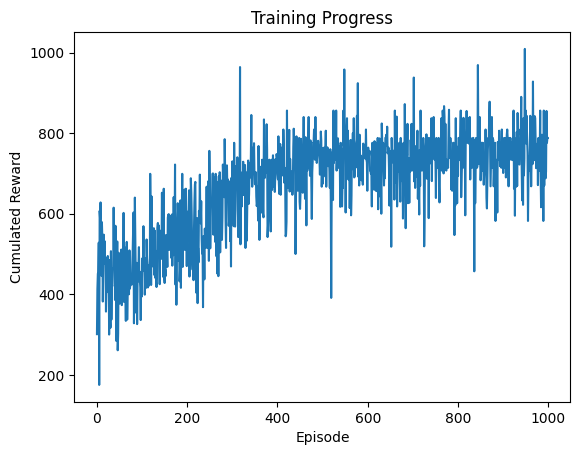

In [6]:
plt.plot(reward_history)
plt.xlabel("Episode")
plt.ylabel("Cumulated Reward")
plt.title("Training Progress")
plt.show()

In [ ]:
import torch

net = agent.policy_net
K = net.K

# Einen echten State holen
obs, _ = env.reset()
state_t = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)

with torch.no_grad():
    q_dqn   = net.dqn(state_t)
    q_total = net(state_t)
    bonus   = q_total - q_dqn

print(f"Q_dqn:   {q_dqn.numpy().flatten()}")
print(f"Bonus:   {bonus.numpy().flatten()[0]:.3f}")
print(f"Q_total: {q_total.numpy().flatten()}")

Q_dqn:   [266.20764 297.64532 296.76096 300.2083 ]
Bonus:   2.319
Q_total: [268.52686 299.96454 299.08017 302.52753]


Teste ob der Bonus einen wirklichen Einfluss hat

In [7]:
import torch

net = agent.policy_net
K = net.K

# Einen echten State holen
obs, _ = env.reset()
state_t = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)

with torch.no_grad():
    q_dqn   = net.dqn(state_t)
    q_total = net(state_t)
    bonus   = q_total - q_dqn

print(f"Q_dqn:   {q_dqn.numpy().flatten()}")
print(f"Bonus:   {bonus.numpy().flatten()[0]:.3f}")
print(f"Q_total: {q_total.numpy().flatten()}")

Q_dqn:   [260.19516 294.86087 291.93985 291.72427]
Bonus:   4.397
Q_total: [264.59213 299.25784 296.33682 296.12125]


Bonus erfüllt die Monotonieeigenschaft

In [8]:
for c_val in [0.0, 5.0, 10.0]:
    c_raw = torch.tensor([[c_val] * K], dtype=torch.float32)
    with torch.no_grad():
        c_cal = torch.cat(
            [cal(c_raw[:, k:k+1].double()).float()
             for k, cal in enumerate(net.c_calibrators)],
            dim=1,
        )
        bonus = net.c_lattice(c_cal.double()).float().item()
    print(f"C_k = {c_val:.0f}  →  Bonus = {bonus:.3f}")

C_k = 0  →  Bonus = 1.263
C_k = 5  →  Bonus = 4.376
C_k = 10  →  Bonus = 4.397
